In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB


In [10]:
df = pd.read_csv(r"C:\Users\muhammed suhail\Desktop\Spam_Mail_Detection\data\spam.csv", encoding='latin-1')

In [11]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [13]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [14]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [15]:
df['label'] = df['label'].map({'ham': 0,'spam': 1})

In [16]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

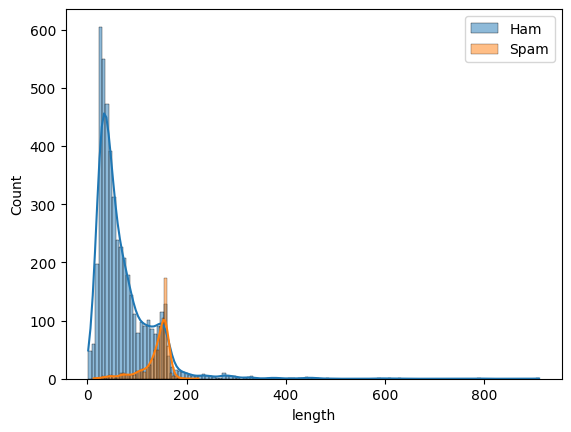

In [18]:
df['length'] = df['message'].apply(len)
sns.histplot(df[df['label']==0]['length'],label='Ham', kde=True)
sns.histplot(df[df['label']==1]['length'],label='Spam', kde=True)
plt.legend()
plt.show()

In [19]:
cv = CountVectorizer()
X = cv.fit_transform(df['message'])
y = df['label']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.naive_bayes import MultinomialNB

In [28]:
model = MultinomialNB()
model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [29]:
y_pred = model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.97847533632287


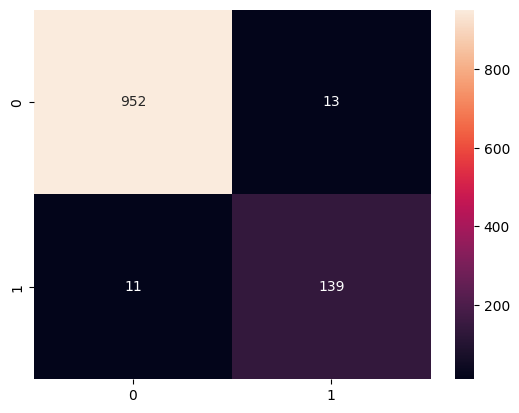

In [31]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [35]:
msg = ["Congratulations! You won a free lottery ticket"]
msg_transformed = cv.transform(msg)

predict = model.predict(msg_transformed)
print("prediction")  # 1= spam, 0 = not spam

prediction
